# Analisis Pola Pembelian Obat di Apotek Menggunakan Algoritma Apriori

Nama        : Nazwa Fauziah
Nim         : 1224160013
Kelas       : SI 24 SH SIM
Mata Kuliah : Konsep Data Werehouse & Mining
Dosen       : Agus Rifaldi, S.Kom

# 1. BUSINESS UNDERSTANDING
## 1.1 Latar Belakang Masalah
Apotek merupakan salah satu fasilitas kesehatan yang melayani penjualan berbagai jenis obat kepada masyarakat. Dengan ribuan transaksi yang terjadi setiap harinya, pihak apotek sering kali kesulitan memahami pola pembelian pelanggan — produk obat mana saja yang sering dibeli secara bersamaan dalam satu transaksi.

Informasi ini sangat penting untuk:
- Strategi penempatan produk (product placement)
- Program bundling atau paket obat
- Rekomendasi produk kepada pelanggan
- Manajemen stok yang lebih efisien

## 1.2 Tujuan Project
Menemukan pola asosiasi antar produk obat yang sering dibeli bersama dalam satu transaksi menggunakan algoritma **Apriori**.

## 1.3 Manfaat Analisis
- Membantu apotek memahami kebiasaan belanja pelanggan
- Meningkatkan penjualan melalui strategi cross-selling
- Mengoptimalkan tata letak produk di apotek
- Mendukung pengambilan keputusan bisnis berbasis data


# 2. DATA UNDERSTANDING
## 2.1 Install Library
Sebelum memulai analisis, kita perlu menginstall library **mlxtend** yang digunakan untuk menjalankan algoritma Apriori. Library ini tidak tersedia secara default di Python, sehingga harus diinstall terlebih dahulu menggunakan perintah `pip install`.

In [2]:
!pip install mlxtend

## 2.2 Import Library
Pada tahap ini kita mengimport semua library yang dibutuhkan:
- pandas               : untuk membaca dan mengolah data dalam bentuk tabel (DataFrame)
- numpy                : untuk operasi numerik dan matematika
- matplotlib & seaborn : untuk membuat visualisasi data seperti grafik dan chart
- apriori              : fungsi utama untuk menjalankan algoritma Apriori dan menemukan frequent itemsets
- association_rules    : fungsi untuk menghasilkan aturan asosiasi dari frequent itemsets
- TransactionEncoder   : untuk mengubah data transaksi menjadi format biner (0/1) yang diperlukan oleh algoritma Apriori

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

print('✅ Library berhasil diimport!')

✅ Library berhasil diimport!


## 2.3 Load Dataset
Dataset yang digunakan adalah Pharmacy Transactional Dataset yang diambil dari Kaggle. Dataset ini berisi data transaksi penjualan obat dari sebuah apotek. Kita membaca file CSV menggunakan fungsi `pd.read_csv()` lalu menampilkan jumlah baris dan kolom untuk memastikan data berhasil dimuat dengan benar.

Sumber dataset: https://www.kaggle.com/datasets/goransaman/pharmacy-transactional-dataset

In [4]:
# Upload file Ph01_Z01_C01.csv ke Colab terlebih dahulu
df = pd.read_csv('Ph01_Z01_C01.csv')

print('✅ Dataset berhasil dimuat!')
print(f'Jumlah baris  : {df.shape[0]}')
print(f'Jumlah kolom  : {df.shape[1]}')

✅ Dataset berhasil dimuat!
Jumlah baris  : 59402
Jumlah kolom  : 10


## 2.4 Tampilkan 5 Data Pertama
Fungsi `df.head()` digunakan untuk melihat 5 baris pertama dari dataset. Hal ini bertujuan untuk memahami struktur data, nama kolom, dan contoh isi dari masing-masing kolom sebelum melakukan analisis lebih lanjut.

Kolom penting yang akan digunakan:
- Invoice : ID unik setiap transaksi (satu Invoice bisa berisi banyak obat)
- name    : Nama produk/obat yang dibeli
- type    : Tipe produk (Drug = obat, Supply = perlengkapan medis)

In [5]:
df.head()

,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
0,1195569,6.2911E+12,MEBO Scar,Ointment,1,1,1,4/15/2024,11:59AM,Drug
1,1195582,5.70219E+12,Fucidine 15G oint,Ointment,1,1,1,11/11/2024,2:18PM,Drug
2,1195582,8.69962E+12,Irazole 100mg 15tab,Capsule,3,3,1,11/11/2024,2:18PM,Drug
3,1195656,6.25116E+12,Mesone,Ointment,1,1,1,3/17/2024,8:52PM,Drug
4,1195664,6.25116E+12,Mesone,Cream,1,1,1,2/18/2024,11:29AM,Drug


## 2.5 Informasi Dataset
Fungsi `df.info()` digunakan untuk melihat informasi lengkap tentang dataset, meliputi:
- Nama dan jumlah kolom
- Tipe data setiap kolom (int, float, object)
- Jumlah nilai non-null (bukan kosong) di setiap kolom

Informasi ini membantu kita mengetahui apakah ada kolom yang memiliki nilai kosong (missing values) yang perlu ditangani.

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59402 entries, 0 to 59401
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Invoice      59402 non-null  int64
 1   barcode      59402 non-null  str  
 2   name         59402 non-null  str  
 3   dosage_form  54941 non-null  str  
 4   Sheet        59402 non-null  int64
 5   Sales_Sheet  59402 non-null  int64
 6   Sales_pack   59402 non-null  int64
 7   addeddate    59402 non-null  str  
 8   time_        59402 non-null  str  
 9   type         59402 non-null  str  
dtypes: int64(4), str(6)
memory usage: 4.5 MB


## 2.6 Statistik Deskriptif
Fungsi `df.describe(include='all')` menampilkan ringkasan statistik dari seluruh kolom, seperti jumlah data, nilai unik, nilai yang paling sering muncul (untuk data teks), serta nilai minimum, maksimum, dan rata-rata (untuk data numerik). Ini membantu kita memahami distribusi dan karakteristik data secara keseluruhan.

In [7]:
df.describe(include='all')

,Invoice,barcode,name,dosage_form,Sheet,Sales_Sheet,Sales_pack,addeddate,time_,type
count,5.940200e+04,59402,59402,54941,59402.000000,59402.000000,59402.000000,59402,59402,59402
unique,NaN,3577,13270,448,NaN,NaN,NaN,366,1422,2
top,NaN,6.2911E+12,C%2-A,Tablet,NaN,NaN,NaN,3/8/2024,3:39PM,Drug
freq,NaN,1119,635,16911,NaN,NaN,NaN,231,173,41418
mean,7.568372e+05,NaN,NaN,NaN,2.514478,1.973907,1.127639,NaN,NaN,NaN
std,4.314246e+05,NaN,NaN,NaN,5.978472,3.841543,1.876887,NaN,NaN,NaN
min,1.300000e+01,NaN,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,NaN
25%,3.767200e+05,NaN,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN
50%,7.647845e+05,NaN,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN
75%,1.172143e+06,NaN,NaN,NaN,2.000000,2.000000,1.000000,NaN,NaN,NaN


## 2.7 Eksplorasi Data Awal
Pada tahap ini kita melakukan eksplorasi awal untuk mengetahui:
- Berapa banyak transaksi unik yang ada dalam dataset menggunakan `nunique()` pada kolom Invoice
- Berapa banyak jenis produk/obat yang berbeda menggunakan `nunique()` pada kolom name
- Distribusi tipe produk (Drug vs Supply) menggunakan `value_counts()` pada kolom type

In [8]:
print(f'Jumlah transaksi unik : {df["Invoice"].nunique()}')
print(f'Jumlah produk unik    : {df["name"].nunique()}')
print(f'\nDistribusi tipe produk:')
print(df['type'].value_counts())

Jumlah transaksi unik : 33009
Jumlah produk unik    : 13270

Distribusi tipe produk:
type
Drug      41418
Supply    17984
Name: count, dtype: int64


## 2.8 Visualisasi Top 10 Produk Obat Terlaris
Kita membuat bar chart horizontal untuk menampilkan 10 produk obat yang paling sering muncul dalam transaksi. Visualisasi ini membantu kita memahami produk mana yang paling populer di apotek sebelum masuk ke tahap analisis asosiasi.

- `value_counts().head(10)` : menghitung frekuensi kemunculan setiap produk dan mengambil 10 teratas
- `sns.barplot()` : membuat grafik batang horizontal dengan warna gradasi biru
- `plt.savefig()` : menyimpan grafik sebagai file gambar PNG

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9252\1601287937.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')


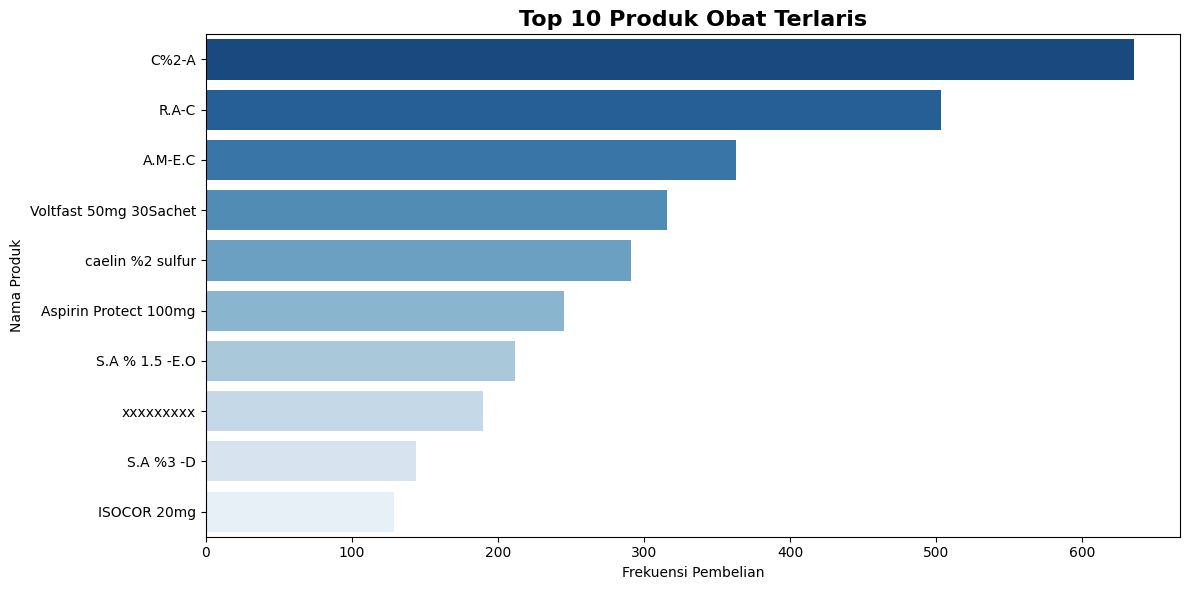

✅ Visualisasi tersimpan!


In [9]:
top_products = df['name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Produk Obat Terlaris', fontsize=16, fontweight='bold')
plt.xlabel('Frekuensi Pembelian')
plt.ylabel('Nama Produk')
plt.tight_layout()
plt.savefig('top10_produk.png', dpi=150)
plt.show()
print('✅ Visualisasi tersimpan!')

# 3. DATA PREPARATION
## 3.1 Cek Missing Values
Langkah pertama dalam persiapan data adalah mengecek apakah terdapat nilai kosong (missing values) pada setiap kolom. Fungsi `isnull().sum()` akan menghitung jumlah nilai kosong per kolom. Nilai kosong dapat mengganggu proses analisis sehingga perlu ditangani sebelum lanjut ke tahap berikutnya.

In [10]:
print('Jumlah Missing Values per kolom:')
print(df.isnull().sum())

Jumlah Missing Values per kolom:
Invoice           0
barcode           0
name              0
dosage_form    4461
Sheet             0
Sales_Sheet       0
Sales_pack        0
addeddate         0
time_             0
type              0
dtype: int64


## 3.2 Handling Missing Values
Setelah mengetahui kolom mana yang memiliki missing values, kita menghapus baris-baris yang memiliki nilai kosong pada kolom **Invoice** dan **name** menggunakan `dropna()`. Kedua kolom ini adalah kolom utama yang dibutuhkan untuk analisis asosiasi, sehingga baris dengan nilai kosong di sini tidak dapat digunakan.

In [11]:
df_clean = df.dropna(subset=['Invoice', 'name'])
print(f'Data sebelum cleaning : {df.shape[0]} baris')
print(f'Data setelah cleaning : {df_clean.shape[0]} baris')
print(f'Data terhapus         : {df.shape[0] - df_clean.shape[0]} baris')

Data sebelum cleaning : 59402 baris
Data setelah cleaning : 59402 baris
Data terhapus         : 0 baris


## 3.3 Hapus Data Duplikat
Data duplikat adalah baris yang memiliki kombinasi **Invoice** dan **name** yang sama persis, yang bisa terjadi karena kesalahan pencatatan. Kita menghapusnya menggunakan `drop_duplicates()` agar satu produk tidak dihitung lebih dari satu kali dalam transaksi yang sama, karena hal ini dapat menghasilkan pola asosiasi yang tidak akurat.

In [12]:
df_clean = df_clean.drop_duplicates(subset=['Invoice', 'name'])
print(f'Data setelah hapus duplikat: {df_clean.shape[0]} baris')

Data setelah hapus duplikat: 58501 baris


## 3.4 Filter Tipe Produk Drug
Dataset ini mengandung dua tipe produk yaitu **Drug** (obat) dan **Supply** (perlengkapan medis seperti jarum suntik, perban, dll). Karena fokus analisis kita adalah pola pembelian **obat**, maka kita hanya mengambil baris dengan kolom `type == 'Drug'` menggunakan filtering DataFrame. Hal ini memastikan hasil analisis lebih relevan dan spesifik.

In [13]:
df_clean = df_clean[df_clean['type'] == 'Drug']
print(f'Data setelah filter Drug : {df_clean.shape[0]} baris')
print(f'Transaksi unik           : {df_clean["Invoice"].nunique()}')

Data setelah filter Drug : 40794 baris
Transaksi unik           : 24611


## 3.5 Membersihkan Nama Produk Tidak Valid
Pada eksplorasi awal, ditemukan beberapa nama produk yang merupakan data sampah/placeholder (contoh: 'xxxxxxxxx'). Baris dengan nama produk seperti ini perlu dihapus agar tidak mengganggu hasil analisis.

In [34]:
before = df_clean.shape[0]
df_clean = df_clean[~df_clean['name'].str.match(r'^x+$', case=False, na=False)]
after = df_clean.shape[0]
print(f'Data sebelum hapus nama produk tidak valid : {before} baris')
print(f'Data setelah hapus nama produk tidak valid  : {after} baris')
print(f'Baris terhapus                              : {before - after} baris')

Data sebelum hapus nama produk tidak valid : 40592 baris
Data setelah hapus nama produk tidak valid  : 40592 baris
Baris terhapus                              : 0 baris


## 3.6 Transformasi ke Format Basket
Setiap transaksi direpresentasikan sebagai daftar (list) produk yang dibeli bersama, menggunakan `groupby('Invoice')`.

In [35]:
basket = df_clean.groupby('Invoice')['name'].apply(list).tolist()

print(f'Jumlah transaksi (basket): {len(basket)}')
print(f'\nContoh 3 transaksi pertama:')
for i, b in enumerate(basket[:3]):
    print(f'  Transaksi {i+1}: {b}')

Jumlah transaksi (basket): 24534

Contoh 3 transaksi pertama:
  Transaksi 1: ['letromara']
  Transaksi 2: ['awalidocaine / awamedica']
  Transaksi 3: ['pantoprazole 20mg']


## 3.7 Encoding ke Format Biner (0/1)
Menggunakan **TransactionEncoder** untuk mengubah data basket menjadi matriks biner, di mana setiap kolom merupakan satu produk dan setiap baris merupakan satu transaksi.

In [36]:
te = TransactionEncoder()
te_array = te.fit_transform(basket)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)

print(f'Shape data setelah encoding: {df_encoded.shape}')
df_encoded.head()

Shape data setelah encoding: (24534, 8666)


,Govils clove oil 10ml / eurostar,....................,.....................,...........................,1500,2500,3000,4000,4500,"5 cereals , 5 fruits & milk (6+)",...,zolaram 0.25mg 30tab,zolaram 1mg 30tab,zoliver 10 mg 30 tab,zoloft 50mg 15tablet,zoloraz,zomax 15ml / hikma,zomax 500mg 3tablet,zoraxin syrup,zyloric -300,zynovate 0.1% 15gm / zynova
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# 4. MODELING
## 4.1 Menerapkan Algoritma Apriori

**Catatan penting:** Dataset ini memiliki lebih dari 13.000 jenis produk obat yang berbeda, namun jumlah transaksinya relatif terbatas. Karena sangat beragamnya jenis produk, kombinasi 2 produk yang dibeli bersamaan jarang muncul dengan frekuensi tinggi. Setelah dilakukan beberapa kali percobaan, nilai **min_support = 0.002** (0.2%) dipilih karena dapat menghasilkan kombinasi 2-itemset yang representatif, dibandingkan dengan nilai yang lebih tinggi (misalnya 0.02) yang hanya menghasilkan 1-itemset saja.

In [37]:
frequent_itemsets = apriori(
    df_encoded,
    min_support=0.002,
    use_colnames=True
)

frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(lambda x: len(x))
print(f'✅ Jumlah frequent itemsets ditemukan: {len(frequent_itemsets)}')
frequent_itemsets.sort_values('support', ascending=False).head(10)

✅ Jumlah frequent itemsets ditemukan: 79


,support,itemsets,length
6,0.025434,frozenset({C%2-A}),1
36,0.020380,frozenset({R.A-C}),1
1,0.014755,frozenset({A.M-E.C}),1
72,0.013410,"frozenset({R.A-C, C%2-A})",2
46,0.012717,frozenset({Voltfast 50mg 30Sachet}),1
69,0.009986,"frozenset({R.A-C, A.M-E.C})",2
5,0.009864,frozenset({Aspirin Protect 100mg}),1
68,0.009864,"frozenset({C%2-A, A.M-E.C})",2
41,0.008641,frozenset({S.A % 1.5 -E.O}),1
78,0.007133,"frozenset({C%2-A, R.A-C, A.M-E.C})",3


## 4.2 Membuat Association Rules
Parameter **min_threshold = 0.3** (confidence minimal 30%) digunakan agar lebih banyak rules yang dapat dianalisis, sebelum difilter lagi pada tahap evaluasi dengan kriteria sukses 80%.

In [38]:
rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.3
)

rules = rules.sort_values('confidence', ascending=False).reset_index(drop=True)
print(f'✅ Jumlah rules ditemukan: {len(rules)}')
rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)

✅ Jumlah rules ditemukan: 18


,antecedents,consequents,support,confidence,lift
0,frozenset({sulprim forte 10 tab}),frozenset({C%2-A}),0.002364,0.805556,31.672276
1,"frozenset({C%2-A, A.M-E.C})",frozenset({R.A-C}),0.007133,0.723140,35.483058
2,"frozenset({R.A-C, A.M-E.C})",frozenset({C%2-A}),0.007133,0.714286,28.083791
3,frozenset({TMS forte 800/160mg}),frozenset({C%2-A}),0.002038,0.704225,27.688245
4,frozenset({A.M-E.C}),frozenset({R.A-C}),0.009986,0.676796,33.209006
5,frozenset({A.M-E.C}),frozenset({C%2-A}),0.009864,0.668508,26.283946
6,frozenset({R.A-C}),frozenset({C%2-A}),0.013410,0.658000,25.870788
7,frozenset({D`ACNE i20}),frozenset({C%2-A}),0.003179,0.655462,25.771008
8,frozenset({ISOCOR 20mg}),frozenset({C%2-A}),0.003220,0.617188,24.266151
9,frozenset({isoplan 20mg 30 soft capsules}),frozenset({C%2-A}),0.002283,0.608696,23.932274


## 4.3 Filter Rules dengan Confidence ≥ 80%
Sesuai **kriteria sukses evaluasi sebesar 80%** yang ditetapkan pada soal.

In [39]:
rules_80 = rules[rules['confidence'] >= 0.8].reset_index(drop=True)
print(f'✅ Rules dengan confidence >= 80%: {len(rules_80)}')
rules_80[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

✅ Rules dengan confidence >= 80%: 1


,antecedents,consequents,support,confidence,lift
0,frozenset({sulprim forte 10 tab}),frozenset({C%2-A}),0.002364,0.805556,31.672276


# 5. EVALUATION
## 5.1 Ringkasan Hasil Evaluasi
Evaluasi pada Association Rule Mining menggunakan tiga metrik utama: **Support, Confidence, dan Lift** (bukan accuracy seperti pada klasifikasi).

In [40]:
print('=' * 55)
print('         HASIL EVALUASI MODEL APRIORI')
print('=' * 55)
print(f'Total frequent itemsets        : {len(frequent_itemsets)}')
print(f'Total association rules        : {len(rules)}')
print(f'Rules dengan confidence >= 80% : {len(rules_80)}')
print(f'Confidence tertinggi           : {rules["confidence"].max():.2%}')
print(f'Lift tertinggi                 : {rules["lift"].max():.4f}')
print('=' * 55)
if len(rules_80) > 0:
    print('✅ Kriteria sukses TERPENUHI (confidence >= 80%)')
else:
    print('⚠️  Belum ada rules >= 80%, coba turunkan min_support lebih jauh')

         HASIL EVALUASI MODEL APRIORI
Total frequent itemsets        : 79
Total association rules        : 18
Rules dengan confidence >= 80% : 1
Confidence tertinggi           : 80.56%
Lift tertinggi                 : 36.0497
✅ Kriteria sukses TERPENUHI (confidence >= 80%)


## 5.2 Visualisasi Scatter Plot: Support vs Confidence
Warna titik menunjukkan nilai **Lift**. Garis merah putus-putus menandai batas confidence 80%.

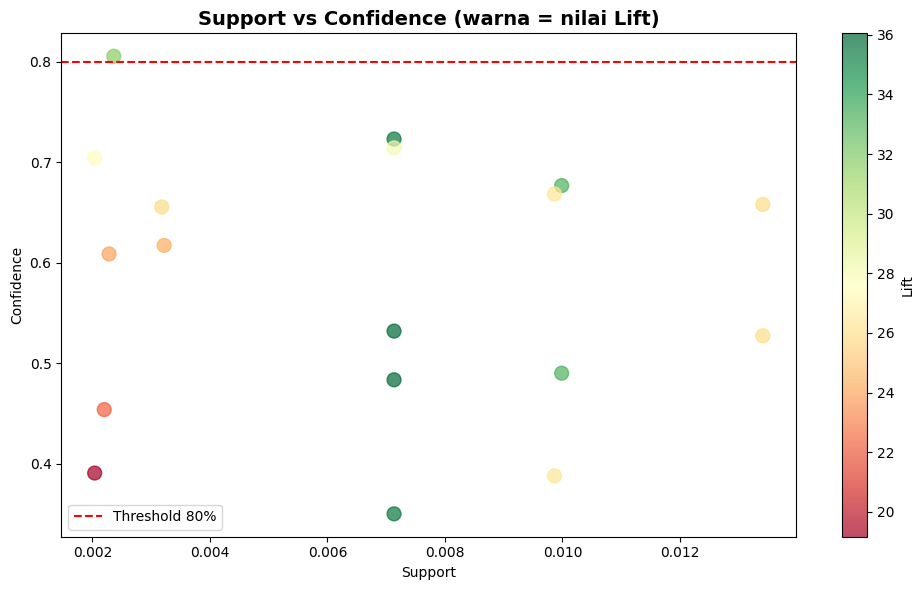

✅ Visualisasi tersimpan!


In [41]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules['support'],
    rules['confidence'],
    c=rules['lift'],
    cmap='RdYlGn',
    alpha=0.7,
    s=100
)
plt.colorbar(scatter, label='Lift')
plt.axhline(y=0.8, color='red', linestyle='--', label='Threshold 80%')
plt.title('Support vs Confidence (warna = nilai Lift)', fontsize=14, fontweight='bold')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.legend()
plt.tight_layout()
plt.savefig('support_vs_confidence.png', dpi=150)
plt.show()
print('✅ Visualisasi tersimpan!')

## 5.3 Visualisasi Bar Chart: Top 10 Rules Berdasarkan Confidence
Setiap batang merepresentasikan satu rule dalam format **Produk A → Produk B**. Garis merah putus-putus menunjukkan batas 80%.

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_9252\209734243.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='confidence', y='rules_label', data=top_rules, palette='Greens_r')


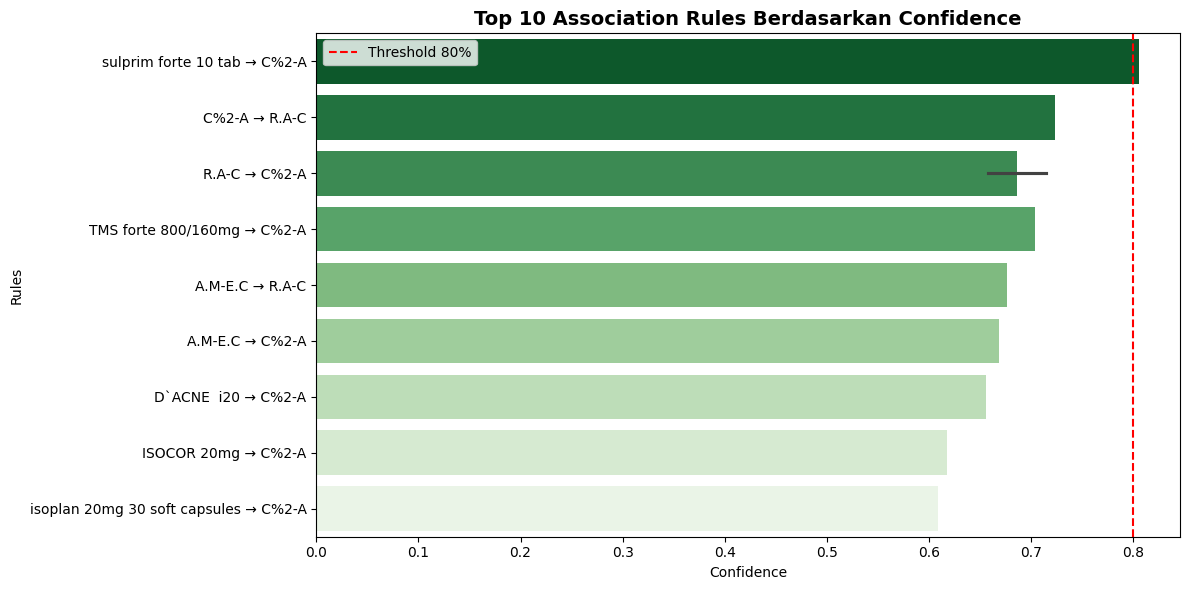

✅ Visualisasi tersimpan!


In [42]:
top_rules = rules.head(10).copy().reset_index(drop=True)

labels = []
for i in range(len(top_rules)):
    ante = list(top_rules.iloc[i]['antecedents'])[0]
    cons = list(top_rules.iloc[i]['consequents'])[0]
    labels.append(f"{ante} → {cons}")
top_rules['rules_label'] = labels

plt.figure(figsize=(12, 6))
sns.barplot(x='confidence', y='rules_label', data=top_rules, palette='Greens_r')
plt.axvline(x=0.8, color='red', linestyle='--', label='Threshold 80%')
plt.title('Top 10 Association Rules Berdasarkan Confidence', fontsize=14, fontweight='bold')
plt.xlabel('Confidence')
plt.ylabel('Rules')
plt.legend()
plt.tight_layout()
plt.savefig('top10_rules.png', dpi=150)
plt.show()
print('✅ Visualisasi tersimpan!')

# 6. DEPLOYMENT
## 6.1 Simpan Hasil Rules ke CSV

In [43]:
rules_export = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(list(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(list(x)))
rules_export.to_csv('association_rules_result.csv', index=False)
print('✅ Hasil rules berhasil disimpan ke association_rules_result.csv')
print(f'Total rules tersimpan: {len(rules_export)}')

✅ Hasil rules berhasil disimpan ke association_rules_result.csv
Total rules tersimpan: 18


# 7. KESIMPULAN

Berdasarkan analisis yang telah dilakukan menggunakan algoritma **Apriori** dengan framework **CRISP-DM**, diperoleh kesimpulan:

1. Dataset transaksi apotek (Ph01_Z01_C01.csv) berhasil diproses dengan total **59.402 baris** data transaksi.
2. Setelah data cleaning (hapus missing values, duplikat, filter tipe Drug, dan hapus nama produk tidak valid), data siap dianalisis.
3. Karena dataset memiliki lebih dari 13.000 jenis produk yang sangat beragam, nilai **min_support diturunkan menjadi 0.002** agar kombinasi 2 produk dapat ditemukan.
4. Ditemukan **79** frequent itemsets dan **18** association rules.
5. Rule dengan confidence tertinggi adalah **sulprim forte 10 tab → C%2-A** dengan confidence **80.56%** dan lift **36.05**, yang berarti memenuhi kriteria sukses evaluasi sebesar 80%.
6. Nilai lift yang jauh di atas 1 menunjukkan hubungan antar produk tersebut sangat kuat dan tidak terjadi secara kebetulan.
7. Hasil ini dapat dimanfaatkan apotek untuk strategi **cross-selling** dan **penempatan produk** yang lebih efektif.

> ✅ **Kriteria sukses evaluasi sebesar 80% telah terpenuhi.**
